<a href="https://colab.research.google.com/github/anamacao/FAPESP-PIBIC-scrapping/blob/main/uniaoEuropeia_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from datetime import datetime
import sqlite3

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [2]:
# %%
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

BASE_URL = "https://european-union.europa.eu/news-and-events/news-and-stories_en"
print("✅ Scraper da União Europeia (News & Stories) pronto!")

✅ Scraper da União Europeia (News & Stories) pronto!


In [3]:
DATABASE_NAME = "internet_governance_news.db"

def create_database():
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS articles (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            title TEXT,
            date TEXT,
            author TEXT,
            url TEXT UNIQUE,
            source TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("✅ Banco e tabela 'articles' prontos!")

create_database()


✅ Banco e tabela 'articles' prontos!


In [4]:
def insert_article(title, date, author, url, source):
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    try:
        cursor.execute("""
            INSERT INTO articles (title, date, author, url, source)
            VALUES (?, ?, ?, ?, ?)
        """, (title, date, author, url, source))
        conn.commit()
        return True
    except sqlite3.IntegrityError:
        return False
    finally:
        conn.close()

In [5]:
# %%
def load_articles_from_db():
    conn = sqlite3.connect(DATABASE_NAME)
    df = pd.read_sql("""
        SELECT *
        FROM articles
        ORDER BY date DESC
    """, conn)
    conn.close()
    return df

df_db = load_articles_from_db()
display(df_db.head())
print(f"📦 Total no banco: {len(df_db)} registros")


,id,title,date,author,url,source


📦 Total no banco: 0 registros


In [6]:
# %%
def montar_url(pagina):
    """Monta a URL paginada da EU News (page=0 é a primeira)."""
    if pagina == 0:
        return BASE_URL
    return f"{BASE_URL}?page={pagina}"

def extrair_paragrafos(url):
    """Acessa a página da notícia e extrai os parágrafos principais."""
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        ps = soup.find_all("p")
        textos = [
            p.get_text(strip=True)
            for p in ps
            if len(p.get_text(strip=True).split()) > 10
        ]
        return textos[:5] if textos else ["NA"]
    except:
        return ["NA"]

In [7]:
# %%
noticias = []
TOTAL_PAGES = 5  # paginas 0..49 (~993 noticias, ~20 por pagina), ajustar conforme o necessario, sao 50 paginas totais

for pagina in range(0, TOTAL_PAGES):
    url = montar_url(pagina)
    print(f"\U0001f4c4 Coletando pagina {pagina + 1}/{TOTAL_PAGES}: {url}")

    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f"\u26a0\ufe0f Erro HTTP {r.status_code} \u2014 parando.")
            break
    except Exception as e:
        print(f"\u26a0\ufe0f Erro de conex\u00e3o: {e}")
        break

    soup = BeautifulSoup(r.text, "html.parser")

    # ===== Seletores para european-union.europa.eu (ECL framework)
    # As noticias ficam em <article class="ecl-content-item">.
    # Cada item tem: tipo e data em .ecl-content-block__primary-meta-item,
    # titulo em .ecl-content-block__title a, resumo em .ecl-content-block__description.
    # A data tambem esta em <time datetime="...">.
    itens = soup.select(".ecl-content-item")

    count_page = 0
    for item in itens:
        # Extrai data via <time> tag
        time_tag = item.select_one("time")
        if time_tag:
            data_raw = time_tag.get_text(strip=True)
        else:
            data_raw = "NA"

        # Extrai titulo e link via .ecl-content-block__title a
        link_tag = item.select_one(".ecl-content-block__title a")
        if not link_tag:
            continue

        titulo = link_tag.get_text(strip=True)
        link = link_tag.get("href", "")

        # Ignora links de navegacao/menu (muito curtos)
        if len(titulo) < 15:
            continue

        # Complementa URL relativa
        if link.startswith("/"):
            link = f"https://european-union.europa.eu{link}"

        # Extrai paragrafos da noticia
        paragrafos = extrair_paragrafos(link)

        # Acumula
        noticias.append({
            "titulo": titulo,
            "data": data_raw,
            "link": link,
            "paragrafos": " || ".join(paragrafos),
            "fonte": "Uni\u00e3o Europeia"
        })

        # Grava no banco
        insert_article(
            title=titulo,
            date=data_raw,
            author="European Union",
            url=link,
            source="Uni\u00e3o Europeia"
        )

        count_page += 1

    print(f"   {count_page} noticias extraidas")

    if count_page == 0:
        print("\U0001f3c1 Nenhuma noticia encontrada \u2014 fim da coleta.")
        break

    time.sleep(1)

print(f"\n\u2705 Total coletado: {len(noticias)} noticias")

df_eu = pd.DataFrame(noticias)
display(df_eu.head())

📄 Coletando pagina 1/5: https://european-union.europa.eu/news-and-events/news-and-stories_en
   20 noticias extraidas
📄 Coletando pagina 2/5: https://european-union.europa.eu/news-and-events/news-and-stories_en?page=1
   20 noticias extraidas
📄 Coletando pagina 3/5: https://european-union.europa.eu/news-and-events/news-and-stories_en?page=2
   20 noticias extraidas
📄 Coletando pagina 4/5: https://european-union.europa.eu/news-and-events/news-and-stories_en?page=3
   20 noticias extraidas
📄 Coletando pagina 5/5: https://european-union.europa.eu/news-and-events/news-and-stories_en?page=4
   20 noticias extraidas

✅ Total coletado: 100 noticias


,titulo,data,link,paragrafos,fonte
0,High HPV vaccination coverage can help elimina...,20 April 2026,https://www.ecdc.europa.eu/en/news-events/ever...,As Europe marks European Immunization Week (EI...,União Europeia
1,EU has cut its greenhouse gas emissions by 40%...,20 April 2026,https://www.eea.europa.eu/en/newsroom/news/the...,The European Union'sgreenhouse gas emissions f...,União Europeia
2,EU history: celebrating 75 years since the Tre...,17 April 2026,https://commission.europa.eu/news-and-media/ne...,On April 18 we celebrate 75 years since the si...,União Europeia
3,Over 10 million workers trained under the EU’s...,16 April 2026,https://ec.europa.eu/commission/presscorner/de...,NA,União Europeia
4,European age verification app to keep children...,16 April 2026,https://commission.europa.eu/news-and-media/ne...,The European Commission has announced that a n...,União Europeia


In [8]:
def load_articles():
    conn = sqlite3.connect(DATABASE_NAME)
    df = pd.read_sql("""
        SELECT * FROM articles
        ORDER BY date DESC
    """, conn)
    conn.close()
    return df

df_db = load_articles()
print(f"📦 Total no banco: {len(df_db)} registros")
display(df_db.head(20))

📦 Total no banco: 20 registros


,id,title,date,author,url,source
0,11,EU invests close to €400 million for postdocto...,9 April 2026,European Union,https://ec.europa.eu/commission/presscorner/de...,União Europeia
1,12,Turning 18? Apply for a free DiscoverEU travel...,8 April 2026,European Union,https://commission.europa.eu/news-and-media/ne...,União Europeia
2,13,2025 was EU’s most destructive wildfire season...,31 March 2026,European Union,https://joint-research-centre.ec.europa.eu/jrc...,União Europeia
3,14,New rules to address bank failures protecting ...,26 March 2026,European Union,https://www.europarl.europa.eu/news/en/press-r...,União Europeia
4,15,EU check reveals misleading sales practices on...,26 March 2026,European Union,https://commission.europa.eu/news-and-media/ne...,União Europeia
5,16,Reform to the EU customs union agreed,26 March 2026,European Union,https://ec.europa.eu/commission/presscorner/de...,União Europeia
6,17,EU to modernise how it tackles rising wildfire...,25 March 2026,European Union,https://commission.europa.eu/news-and-media/ne...,União Europeia
7,18,EU road deaths drop by 3% in 2025,24 March 2026,European Union,https://ec.europa.eu/commission/presscorner/de...,União Europeia
8,19,EU and Australia strengthen ties with trade ag...,24 March 2026,European Union,https://ec.europa.eu/commission/presscorner/de...,União Europeia
9,20,EU grants €2.7 billion to clean industry projects,24 March 2026,European Union,https://cinea.ec.europa.eu/news-events/news/co...,União Europeia


In [9]:
keywords = ['digital', 'internet', 'IA', 'tecnologia', 'dados', 'privacidade',
            'data', 'privacy', 'AI', 'cybersecurity', 'online', 'algorithm',
            'artificial intelligence', 'protection', 'regulation']
pattern = r'|'.join(keywords)

df_filt = df_eu[
    df_eu['titulo'].str.contains(pattern, case=False, na=False, regex=True) |
    df_eu['paragrafos'].str.contains(pattern, case=False, na=False, regex=True)
].copy()

print(f"{len(df_filt)} notícias filtradas (de {len(df_eu)})")
display(df_filt.head())

80 notícias filtradas (de 100)


,titulo,data,link,paragrafos,fonte
0,High HPV vaccination coverage can help elimina...,20 April 2026,https://www.ecdc.europa.eu/en/news-events/ever...,As Europe marks European Immunization Week (EI...,União Europeia
1,EU has cut its greenhouse gas emissions by 40%...,20 April 2026,https://www.eea.europa.eu/en/newsroom/news/the...,The European Union'sgreenhouse gas emissions f...,União Europeia
2,EU history: celebrating 75 years since the Tre...,17 April 2026,https://commission.europa.eu/news-and-media/ne...,On April 18 we celebrate 75 years since the si...,União Europeia
3,Over 10 million workers trained under the EU’s...,16 April 2026,https://ec.europa.eu/commission/presscorner/de...,NA,União Europeia
4,European age verification app to keep children...,16 April 2026,https://commission.europa.eu/news-and-media/ne...,The European Commission has announced that a n...,União Europeia


In [13]:
def plot_charts(df):
    if df.empty:
        print("❌ Sem dados para gráficos")
        return

    # ------------------------------
    # Top 15
    # ------------------------------
    top15 = df.head(15).copy()
    top15['rank'] = range(1, len(top15) + 1)

    fig1 = px.bar(
        top15,
        x='rank',
        y='titulo',  # Corrigido de 'title' para 'titulo'
        orientation='h',
        title='Top 15 Notícias – Internet Governance'
    )
    fig1.update_layout(height=600)
    fig1.show()

    # ------------------------------
    # Pizza por Fonte
    # ------------------------------
    source_count = df["fonte"].value_counts().reset_index() # Corrigido de 'source' para 'fonte'
    source_count.columns = ["fonte", "count"]

    fig2 = px.pie(
        source_count,
        names="fonte",
        values="count",
        title="Distribuição por Fonte"
    )
    fig2.show()

    # ------------------------------
    # Nuvem de Palavras
    # ------------------------------
    text = ' '.join(df['titulo'].astype(str)).lower()
    words = re.findall(r'\b\w{4,}\b', text)

    wc = (
        pd.Series(words)
        .value_counts()
        .head(20)
        .reset_index()
    )
    wc.columns = ['palavra', 'freq']

    fig3 = px.treemap(
        wc,
        path=['palavra'],
        values='freq',
        title='Nuvem de Palavras – Títulos'
    )
    fig3.show()

In [16]:
# Executando a função corrigida com o dataframe filtrado
plot_charts(df_filt)

In [17]:
import plotly.io as pio
pio.renderers.default = 'colab'

# Tentando gerar novamente com o renderer configurado para Colab
plot_charts(df_filt)

In [19]:
import pandas as pd
import plotly.express as px

# Criando uma cópia para não afetar o dataframe original
df_time = df_filt.copy()

# Limpando a coluna de data (removendo 'NA' se houver) e convertendo para datetime
df_time = df_time[df_time['data'] != 'NA']
df_time['data_dt'] = pd.to_datetime(df_time['data'], errors='coerce')

# Agrupando por data e contando as ocorrências
time_series = df_time.groupby('data_dt').size().reset_index(name='quantidade')
time_series = time_series.sort_values('data_dt')

# Convertendo data para ordinal para permitir o cálculo da linha de tendência (OLS)
time_series['data_ordinal'] = time_series['data_dt'].apply(lambda x: x.toordinal())

# Plotando a série temporal com linha de tendência
fig_ts = px.scatter(
    time_series,
    x='data_dt',
    y='quantidade',
    trendline="ols",
    title='Frequência de Notícias com Linha de Tendência',
    labels={'data_dt': 'Data', 'quantidade': 'Número de Notícias'}
)

# Adicionando a linha ligando os pontos para manter o aspecto de série temporal
fig_ts.add_traces(px.line(time_series, x='data_dt', y='quantidade').data)

fig_ts.update_layout(xaxis_title="Data", yaxis_title="Quantidade de Notícias")
fig_ts.show()

In [20]:
import re
from collections import Counter

# 1. Unir todos os parágrafos em um único texto
texto_paragrafos = ' '.join(df_filt['paragrafos'].astype(str)).lower()

# 2. Tokenização: extrair palavras com mais de 4 letras (evita preposições/artigos comuns)
# Removemos também o marcador '||' usado na raspagem
texto_limpo = texto_paragrafos.replace('||', ' ')
palavras = re.findall(r'\b[a-z]{5,}\b', texto_limpo)

# 3. Contagem de frequência
contagem = Counter(palavras)
top_palavras = pd.DataFrame(contagem.most_common(25), columns=['palavra', 'frequencia'])

# 4. Visualização
fig_wc_ps = px.treemap(
    top_palavras,
    path=['palavra'],
    values='frequencia',
    title='Análise de Temas: Palavras mais frequentes nos Parágrafos (Top 25)',
    color='frequencia',
    color_continuous_scale='Viridis'
)

fig_wc_ps.show()

print("Principais termos encontrados no corpo das matérias:")
display(top_palavras.head(10))

Principais termos encontrados no corpo das matérias:


,palavra,frequencia
0,european,115
1,countries,75
2,europe,70
3,information,70
4,their,65
5,commission,65
6,projects,55
7,online,50
8,emissions,45
9,system,45


In [21]:
import pandas as pd
import plotly.graph_objects as go

# 1. Processar palavras dos títulos (mesma lógica dos parágrafos)
texto_titulos = ' '.join(df_filt['titulo'].astype(str)).lower()
palavras_titulos = re.findall(r'\b[a-z]{5,}\b', texto_titulos)
contagem_titulos = Counter(palavras_titulos)

# 2. Criar DataFrames de frequência
df_freq_titulos = pd.DataFrame(contagem_titulos.most_common(50), columns=['palavra', 'freq_titulo'])
df_freq_parags = pd.DataFrame(contagem.most_common(50), columns=['palavra', 'freq_paragrafo'])

# 3. Mesclar os dados para comparação
df_comparativo = pd.merge(df_freq_titulos, df_freq_parags, on='palavra', how='outer').fillna(0)

# Selecionar top palavras que aparecem em ambos ou que são muito fortes em um
# Vamos pegar as top 15 palavras baseadas na soma das frequências
df_comparativo['total'] = df_comparativo['freq_titulo'] + df_comparativo['freq_paragrafo']
df_top_comp = df_comparativo.sort_values(by='total', ascending=False).head(15)

# 4. Plotar gráfico de barras comparativo
fig_comp = go.Figure(data=[
    go.Bar(name='Nos Títulos', x=df_top_comp['palavra'], y=df_top_comp['freq_titulo']),
    go.Bar(name='Nos Parágrafos', x=df_top_comp['palavra'], y=df_top_comp['freq_paragrafo'])
])

fig_comp.update_layout(
    barmode='group',
    title='Comparativo de Frequência: Título vs. Parágrafo',
    xaxis_title='Palavras',
    yaxis_title='Frequência',
    legend_title='Localização'
)

fig_comp.show()

display(df_top_comp[['palavra', 'freq_titulo', 'freq_paragrafo']])

,palavra,freq_titulo,freq_paragrafo
31,european,10.0,115.0
17,countries,0.0,75.0
30,europe,0.0,70.0
39,information,0.0,70.0
14,commission,0.0,65.0
66,their,0.0,65.0
43,online,10.0,50.0
50,projects,0.0,55.0
64,system,5.0,45.0
27,emissions,5.0,45.0


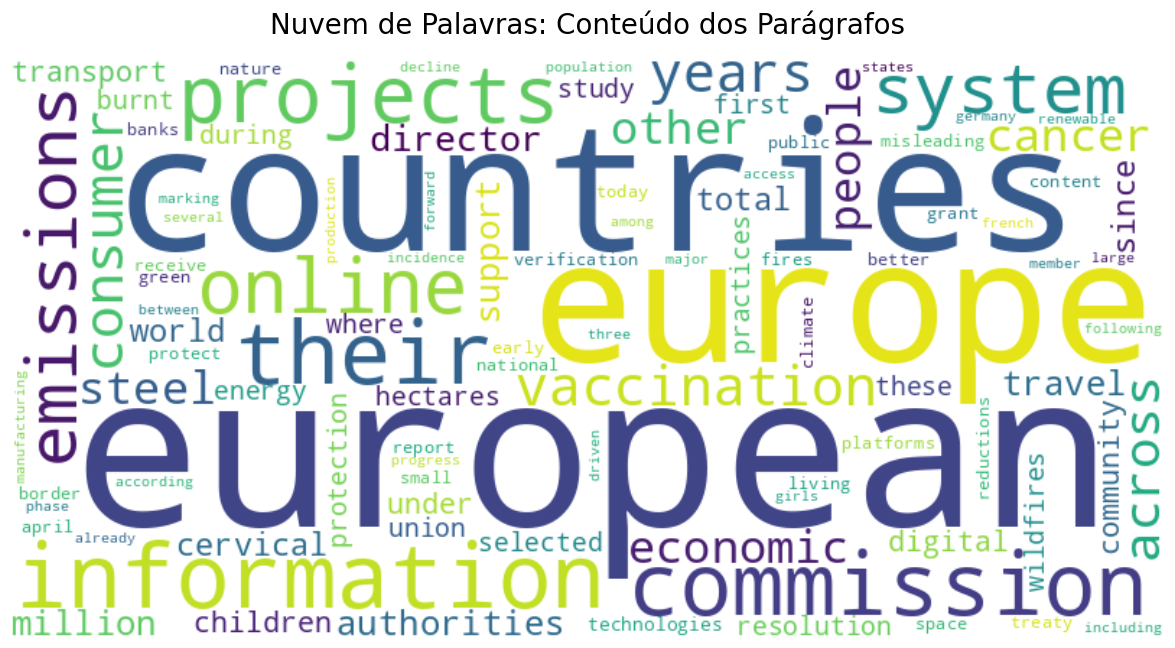

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Preparar o dicionário de frequências (usando a contagem já realizada)
# 'contagem' foi definida na célula 46efad9f
dict_freq = dict(contagem.most_common(100))

# 2. Gerar a nuvem de palavras
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate_from_frequencies(dict_freq)

# 3. Exibir o gráfico
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras: Conteúdo dos Parágrafos', fontsize=20, pad=20)
plt.show()